In [62]:
# ⭐ NOTEBOOK 7 : ANALYSE DU MEILLEUR MODÈLE

## 🎯 Objectif
## Analyser en profondeur le meilleur modèle avec Feature Importance, SHAP values,
## et analyse des erreurs pour générer des insights pour un article scientifique fort.


# Imports standards
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance
import shap
import joblib
import os
import warnings
from scipy import stats
warnings.filterwarnings('ignore')

# Configuration
np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('✅ Imports réussis !')
print(f'✅ SHAP version: {shap.__version__}')

✅ Imports réussis !
✅ SHAP version: 0.50.0


In [63]:
#ÉTAPE 2 : CHARGEMENT DES DONNÉES
print('\n' + '='*80)
print('📥 CHARGEMENT DES DONNÉES')
print('='*80)

# Charger les données
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f'\n✅ Données chargées:')
print(f'   X_train: {X_train.shape}')
print(f'   X_test: {X_test.shape}')
print(f'   y_train: {y_train.shape}')
print(f'   y_test: {y_test.shape}')
print(f'\n📌 Features disponibles: {X_train.shape[1]} variables')
print(f'   Top 5: {list(X_train.columns[:5])}')


📥 CHARGEMENT DES DONNÉES

✅ Données chargées:
   X_train: (3042, 43)
   X_test: (761, 43)
   y_train: (3042,)
   y_test: (761,)

📌 Features disponibles: 43 variables
   Top 5: ['area', 'manure', 'urea', 'npk', 'nitrogen']


In [64]:
## 🏆 ÉTAPE 3 : COMBINER TOUS LES RÉSULTATS ET IDENTIFIER LE MEILLEUR MODÈLE
import pandas as pd

print('\n' + '='*80)
print('🔄 COMBINAISON DE TOUS LES RÉSULTATS')
print('='*80)

# Charger tous les résultats (corriger encodage si nécessaire)
results_baseline = pd.read_csv('../results/04_baseline_comparison.csv', encoding='latin1')
results_tree     = pd.read_csv('../results/05_tree_models_comparison.csv', encoding='latin1')
results_advanced = pd.read_csv('../results/06_advanced_models.csv', encoding='latin1')

# Corriger problème d'encodage colonne "Modèle"
for df in [results_baseline, results_tree, results_advanced]:
    df.rename(columns=lambda x: x.replace("ModÃ¨le", "Modèle"), inplace=True)

print(f'\n✅ Résultats chargés:')
print(f'   Baseline: {len(results_baseline)} modèles')
print(f'   Tree: {len(results_tree)} modèles')
print(f'   Advanced: {len(results_advanced)} modèles')

# Colonnes communes (sécurisé)
common_cols = ['Modèle', 'R2_Test', 'RMSE_Test']

# Ajouter MAE_Test seulement si elle existe
if 'MAE_Test' in results_tree.columns:
    common_cols.append('MAE_Test')

# Combiner proprement
results_all = pd.concat([
    results_baseline.reindex(columns=common_cols),
    results_tree.reindex(columns=common_cols),
    results_advanced.reindex(columns=common_cols)
], ignore_index=True)

# Trier par R² décroissant
results_all = results_all.sort_values('R2_Test', ascending=False).reset_index(drop=True)

print(f'\n📊 TOTAL: {len(results_all)} modèles testés')
print(f'   (NB: les 2 scalers scaler_baseline.pkl et scaler_advanced.pkl ne sont pas comptés')
print(f'   car ce sont des objets de prétraitement, pas des modèles de prédiction)')

print('\n🏆 TOP 5 MODÈLES:')
print('='*80)
for idx, row in results_all.head(5).iterrows():
    mae_str = f", MAE = {row['MAE_Test']:.2f}" if 'MAE_Test' in results_all.columns and pd.notna(row.get('MAE_Test')) else ''
    print(f"{idx+1}. {row['Modèle']:30s} → R² = {row['R2_Test']:.4f}, RMSE = {row['RMSE_Test']:.2f}{mae_str}")

# Meilleur modèle
best = results_all.iloc[0]
print(f'\n🥇 CHAMPION : {best["Modèle"]}')
print(f'   R² Test  : {best["R2_Test"]:.4f}')
print(f'   RMSE Test: {best["RMSE_Test"]:.2f} kg/ha')
if 'MAE_Test' in results_all.columns and pd.notna(best.get('MAE_Test')):
    print(f'   MAE Test : {best["MAE_Test"]:.2f} kg/ha')
else:
    print(f'   MAE Test : non disponible pour ce modèle')

if   best['R2_Test'] > 0.8: perf = '★★★ EXCELLENTE'
elif best['R2_Test'] > 0.6: perf = '★★  TRÈS BONNE'
elif best['R2_Test'] > 0.4: perf = '★   BONNE'
else:                        perf = '    MODÉRÉE'

print(f'\n📊 Performance : {perf}')
print(f'   → Le modèle explique {best["R2_Test"]*100:.1f}% de la variance du rendement')

# Sauvegarde
results_all.to_csv('../results/07_all_models_combined.csv', index=False)
print('\n✅ Résultats combinés sauvegardés: ../results/07_all_models_combined.csv')


🔄 COMBINAISON DE TOUS LES RÉSULTATS

✅ Résultats chargés:
   Baseline: 4 modèles
   Tree: 7 modèles
   Advanced: 3 modèles

📊 TOTAL: 14 modèles testés
   (NB: les 2 scalers scaler_baseline.pkl et scaler_advanced.pkl ne sont pas comptés
   car ce sont des objets de prétraitement, pas des modèles de prédiction)

🏆 TOP 5 MODÈLES:
1. HistGradientBoosting           → R² = 0.1812, RMSE = 821.10, MAE = 642.11
2. CatBoost (opt)                 → R² = 0.1759, RMSE = 823.76, MAE = 644.76
3. Gradient Boosting (opt)        → R² = 0.1752, RMSE = 824.08, MAE = 643.55
4. Random Forest (opt)            → R² = 0.1674, RMSE = 827.97, MAE = 649.83
5. LightGBM (opt)                 → R² = 0.1595, RMSE = 831.89, MAE = 652.00

🥇 CHAMPION : HistGradientBoosting
   R² Test  : 0.1812
   RMSE Test: 821.10 kg/ha
   MAE Test : 642.11 kg/ha

📊 Performance :     MODÉRÉE
   → Le modèle explique 18.1% de la variance du rendement

✅ Résultats combinés sauvegardés: ../results/07_all_models_combined.csv


In [65]:
print('\n' + '='*80)
print('🏆 MEILLEUR MODÈLE IDENTIFIÉ')
print('='*80)

# Meilleur modèle
best_model_info = results_all.iloc[0]
best_model_name = best_model_info['Modèle']
best_r2 = best_model_info['R2_Test']
best_rmse = best_model_info['RMSE_Test']
best_mae = best_model_info['MAE_Test']

print(f'\n🥇 CHAMPION: {best_model_name}')
print(f'   R² Test  : {best_r2:.4f}')
print(f'   RMSE Test : {best_rmse:.2f} kg/ha')
print(f'   MAE Test  : {best_mae:.2f} kg/ha')

# Performance
if best_r2 > 0.8:
    perf = '★★★ EXCELLENTE'
elif best_r2 > 0.6:
    perf = '★★ TRÈS BONNE'
elif best_r2 > 0.4:
    perf = '★ BONNE'
else:
    perf = 'MODÉRÉE'
    
print(f'\n📊 Performance: {perf}')
print(f'   → Le modèle explique {best_r2*100:.1f}% de la variance du rendement')


🏆 MEILLEUR MODÈLE IDENTIFIÉ

🥇 CHAMPION: HistGradientBoosting
   R² Test  : 0.1812
   RMSE Test : 821.10 kg/ha
   MAE Test  : 642.11 kg/ha

📊 Performance: MODÉRÉE
   → Le modèle explique 18.1% de la variance du rendement


## 📦 ÉTAPE 4 : CHARGEMENT DU MEILLEUR MODÈLE

In [66]:
import os
import joblib
import pandas as pd

print('\n' + '='*80)
print('📦 CHARGEMENT DU MODÈLE')
print('='*80)

# Toujours recharger depuis le CSV pour éviter les conflits avec d'anciennes cellules
results_all = pd.read_csv('../results/07_all_models_combined.csv')
best_model_name = results_all.iloc[0]['Modèle'].strip()
print(f'✅ Meilleur modèle (depuis CSV): "{best_model_name}"')

# Mapping exact : noms issus des CSV de résultats → fichiers .pkl réels
model_files_map = {
    # Baseline models (4) — noms issus de 04_baseline_comparison.csv
    'Linear':      '../models/linear_regression.pkl',
    'Ridge':       '../models/ridge_regression.pkl',
    'Lasso':       '../models/lasso_regression.pkl',
    'ElasticNet':  '../models/elasticnet_regression.pkl',

    # Tree models (7) — noms issus de 05_tree_models_comparison.csv
    'Decision Tree (opt)':      '../models/decision_tree.pkl',
    'Random Forest (opt)':      '../models/random_forest.pkl',
    'Gradient Boosting (opt)':  '../models/gradient_boosting.pkl',
    'LightGBM (opt)':           '../models/lightgbm.pkl',
    'CatBoost (opt)':           '../models/catboost.pkl',
    'HistGradientBoosting':     '../models/histgradient.pkl',
    'AdaBoost':                 '../models/adaboost.pkl',

    # Advanced models (3) — noms issus de 06_advanced_models.csv
    'KNN (Optuna)':       '../models/knn.pkl',
    'LinearSVR (Optuna)': '../models/linearsvr.pkl',
    'SGD (Optuna)':       '../models/sgd.pkl',
}

print(f'\n📊 Mapping: {len(model_files_map)} modèles (4 baseline + 7 tree + 3 advanced)')

# Chercher le fichier correspondant
model_path = model_files_map.get(best_model_name)

if model_path is None:
    print(f"\n❌ Modèle '{best_model_name}' non trouvé dans le mapping.")
    print("💡 Modèles disponibles :")
    for k in model_files_map.keys():
        print(f"   - {k}")
    raise ValueError("Arrêt du script : modèle introuvable.")

# Vérifier que le fichier existe
if not os.path.exists(model_path):
    print(f"\n❌ Fichier non trouvé : {model_path}")
    print("💡 Fichiers disponibles dans ../models/ :")
    if os.path.exists('../models'):
        for f in sorted(os.listdir('../models')):
            if f.endswith('.pkl'):
                print(f"   - {f}")
    raise FileNotFoundError("Arrêt du script : fichier modèle absent.")

# Charger le modèle
best_model = joblib.load(model_path)
print(f'\n✅ Modèle chargé avec succès')
print(f'   Nom    : {best_model_name}')
print(f'   Fichier: {model_path}')
print(f'   Type   : {type(best_model).__name__}')


📦 CHARGEMENT DU MODÈLE
✅ Meilleur modèle (depuis CSV): "HistGradientBoosting"

📊 Mapping: 14 modèles (4 baseline + 7 tree + 3 advanced)

✅ Modèle chargé avec succès
   Nom    : HistGradientBoosting
   Fichier: ../models/histgradient.pkl
   Type   : HistGradientBoostingRegressor


## 🎯 ÉTAPE 5 : PRÉDICTIONS ET MÉTRIQUES

In [67]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print('\n' + '='*80)
print('🎯 PRÉDICTIONS ET MÉTRIQUES')
print('='*80)

# ── Chargement des données ────────────────────────────────────────────────────
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f'\n✅ Données chargées:')
print(f'   Train : {X_train.shape[0]} observations, {X_train.shape[1]} features')
print(f'   Test  : {X_test.shape[0]} observations,  {X_test.shape[1]} features')

# ── Prédictions ───────────────────────────────────────────────────────────────
y_train_pred = best_model.predict(X_train)
y_test_pred  = best_model.predict(X_test)

print(f'\n✅ Prédictions effectuées')

# ── Métriques ─────────────────────────────────────────────────────────────────
# Train
r2_train   = r2_score(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
mae_train  = mean_absolute_error(y_train, y_train_pred)

# Test
r2_test    = r2_score(y_test, y_test_pred)
rmse_test  = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_test   = mean_absolute_error(y_test, y_test_pred)

# Overfitting
r2_diff    = r2_train - r2_test
overfitting = 'Oui ⚠️' if r2_diff > 0.1 else 'Non ✅'

print(f'\n📊 MÉTRIQUES DU MODÈLE : {best_model_name}')
print('='*80)
print(f'{"Métrique":<20} {"Train":>12} {"Test":>12}')
print('-'*44)
print(f'{"R²":<20} {r2_train:>12.4f} {r2_test:>12.4f}')
print(f'{"RMSE (kg/ha)":<20} {rmse_train:>12.2f} {rmse_test:>12.2f}')
print(f'{"MAE (kg/ha)":<20} {mae_train:>12.2f} {mae_test:>12.2f}')
print('-'*44)
print(f'{"Surapprentissage":<20} {"R² diff = " + f"{r2_diff:.4f}":>12} {overfitting:>12}')

# ── Performance globale ───────────────────────────────────────────────────────
if   r2_test > 0.8: perf = '★★★ EXCELLENTE'
elif r2_test > 0.6: perf = '★★  TRÈS BONNE'
elif r2_test > 0.4: perf = '★   BONNE'
else:               perf = '    MODÉRÉE'

print(f'\n📊 Performance globale : {perf}')
print(f'   → Le modèle explique {r2_test*100:.1f}% de la variance du rendement')
print(f'   → Erreur moyenne     : {mae_test:.2f} kg/ha')
print(f'   → Erreur max typique : {rmse_test:.2f} kg/ha')

# ── Sauvegarde des prédictions ────────────────────────────────────────────────
predictions_df = pd.DataFrame({
    'y_reel':      y_test.values,
    'y_predit':    y_test_pred,
    'erreur':      y_test.values - y_test_pred,
    'erreur_abs':  np.abs(y_test.values - y_test_pred)
})

predictions_df.to_csv('../results/08_predictions.csv', index=False)
print(f'\n✅ Prédictions sauvegardées: ../results/08_predictions.csv')
print(f'   Colonnes: y_reel, y_predit, erreur, erreur_abs')


🎯 PRÉDICTIONS ET MÉTRIQUES

✅ Données chargées:
   Train : 3042 observations, 43 features
   Test  : 761 observations,  43 features

✅ Prédictions effectuées

📊 MÉTRIQUES DU MODÈLE : HistGradientBoosting
Métrique                    Train         Test
--------------------------------------------
R²                         0.2690       0.1812
RMSE (kg/ha)               776.57       821.10
MAE (kg/ha)                617.29       642.11
--------------------------------------------
Surapprentissage     R² diff = 0.0878        Non ✅

📊 Performance globale :     MODÉRÉE
   → Le modèle explique 18.1% de la variance du rendement
   → Erreur moyenne     : 642.11 kg/ha
   → Erreur max typique : 821.10 kg/ha

✅ Prédictions sauvegardées: ../results/08_predictions.csv
   Colonnes: y_reel, y_predit, erreur, erreur_abs


## 🔍 ÉTAPE 6 : FEATURE IMPORTANCE - PERMUTATION IMPORTANCE

## La Permutation Importance fonctionne pour TOUS les modèles (même KNN, SVR, etc.)

In [68]:
from sklearn.inspection import permutation_importance

print('\n' + '='*80)
print('🔄 PERMUTATION IMPORTANCE')
print('='*80)
print(f'\n🔍 Modèle analysé : {best_model_name}')
print(f'   Features : {X_test.shape[1]}')
print(f'   Observations test : {X_test.shape[0]}')
print('\n⏳ Calcul en cours (peut prendre 1-2 minutes)...')

# Calculer la permutation importance
perm_importance = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring='r2',
    n_jobs=-1
)

# Créer un DataFrame
perm_importance_df = pd.DataFrame({
    'Feature':          X_test.columns,
    'Importance_Mean':  perm_importance.importances_mean,
    'Importance_Std':   perm_importance.importances_std
}).sort_values('Importance_Mean', ascending=False).reset_index(drop=True)

print('\n✅ Calcul terminé !')
print(f'\n📌 TOP 15 FEATURES (Permutation Importance) — {best_model_name}:')
print('='*80)
print(f'{"Rang":<5} {"Feature":<30} {"Importance":>10} {"±":>3} {"Std":>10}')
print('-'*60)
for idx, row in perm_importance_df.head(15).iterrows():
    print(f"{idx+1:<5} {row['Feature']:<30} {row['Importance_Mean']:>10.5f}   {row['Importance_Std']:>10.5f}")

# Features négatives (dégradent le modèle si permutées → peu importantes)
neg_features = perm_importance_df[perm_importance_df['Importance_Mean'] < 0]
if len(neg_features) > 0:
    print(f'\n⚠️  {len(neg_features)} features avec importance négative (bruit potentiel):')
    for idx, row in neg_features.iterrows():
        print(f"   - {row['Feature']:<30} : {row['Importance_Mean']:.5f}")

# Sauvegarder
perm_importance_df.to_csv('../results/08_permutation_importance.csv', index=False)
print(f'\n✅ Sauvegardé: ../results/08_permutation_importance.csv')
print(f'   {len(perm_importance_df)} features analysées')


🔄 PERMUTATION IMPORTANCE

🔍 Modèle analysé : HistGradientBoosting
   Features : 43
   Observations test : 761

⏳ Calcul en cours (peut prendre 1-2 minutes)...

✅ Calcul terminé !

📌 TOP 15 FEATURES (Permutation Importance) — HistGradientBoosting:
Rang  Feature                        Importance   ±        Std
------------------------------------------------------------
1     interaction_rain_area             0.05797      0.00962
2     village_Antsahamamy               0.02628      0.00667
3     rain_year                         0.02306      0.00481
4     soil_hillside                     0.02066      0.00550
5     village_Ambohitsilaozana          0.01361      0.00418
6     rain_cycle                        0.01266      0.00348
7     interaction_ca_rain_year          0.01220      0.00683
8     interaction_till_rain_year        0.01172      0.00480
9     rain_flow                         0.01058      0.00243
10    area                              0.01049      0.00373
11    ratio_N_manu


📊 Création du graphique...


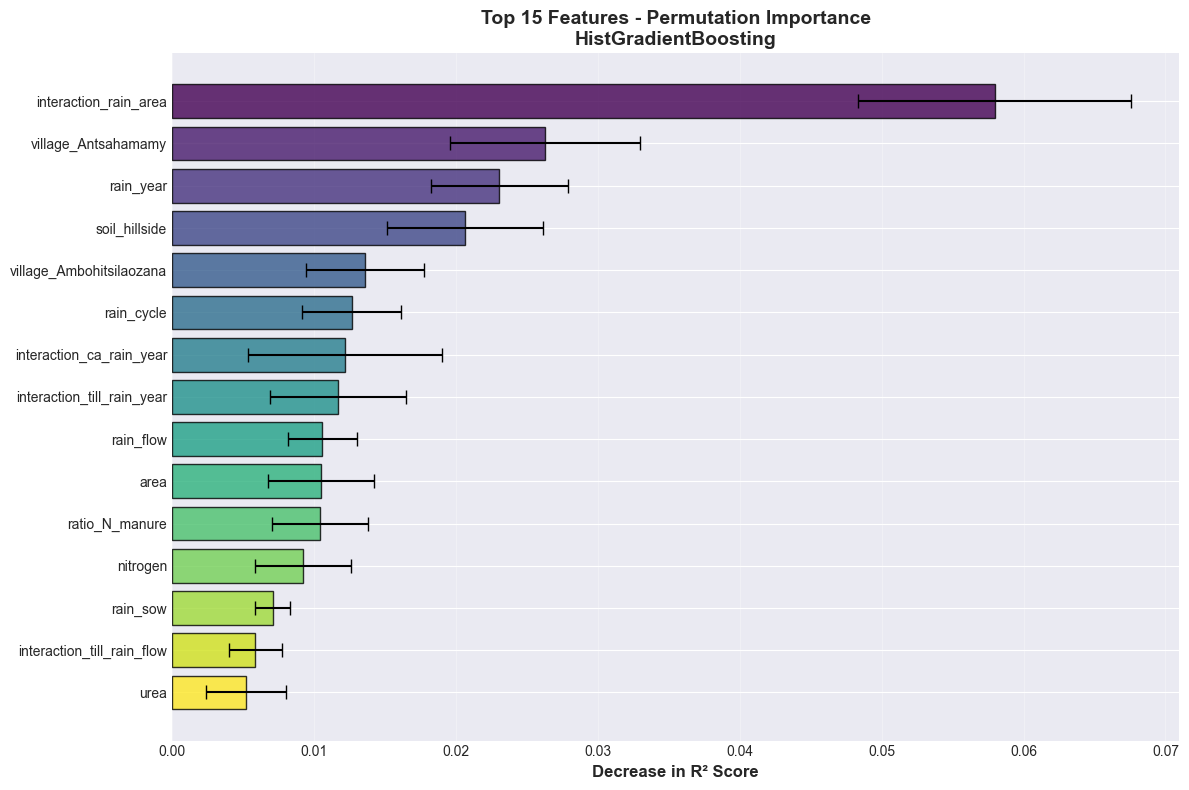

✅ Graphique sauvegardé: ../figures/07_permutation_importance.png


In [69]:
# Graphique de Permutation Importance
print('\n📊 Création du graphique...')

fig, ax = plt.subplots(figsize=(12, 8))

top_features = perm_importance_df.head(15)
colors = plt.cm.viridis(np.linspace(0, 1, len(top_features)))

ax.barh(range(len(top_features)), top_features['Importance_Mean'].values,
        xerr=top_features['Importance_Std'].values,
        color=colors, edgecolor='black', alpha=0.8, capsize=5)

ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'].values)
ax.set_xlabel('Decrease in R² Score', fontsize=12, fontweight='bold')
ax.set_title(f'Top 15 Features - Permutation Importance\n{best_model_name}',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../figures/07_permutation_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print('✅ Graphique sauvegardé: ../figures/07_permutation_importance.png')

## 💡 ÉTAPE 7 : SHAP VALUES - EXPLICATION DU MODÈLE

## SHAP (SHapley Additive exPlanations) explique comment chaque variable contribue aux prédictions.

In [ ]:
print('\n' + '='*80)
print('💡 SHAP VALUES - EXPLICATION DU MODÈLE')
print('='*80)
print(f'\n🔍 Modèle analysé : {best_model_name}')
print(f'   Type           : {type(best_model).__name__}')
print(f'   Features       : {X_test.shape[1]}')
print(f'   Observations   : {X_test.shape[0]}')

# ── Échantillonnage pour accélérer (surtout pour KNN, SVR) ───────────────────
sample_size = min(200, len(X_test))
X_test_sample  = X_test.sample(sample_size, random_state=42)
y_test_sample  = y_test[X_test_sample.index]

print(f'\n📌 Échantillon pour SHAP : {len(X_test_sample)} observations')
print('\n⏳ Création de l\'explainer SHAP...')
print('   (Cela peut prendre 2-5 minutes selon le modèle)')

# ── Création de l'explainer selon le type de modèle ──────────────────────────
try:
    # Modèles tree-based (GradientBoosting, RF, LightGBM, CatBoost, etc.)
    if hasattr(best_model, 'feature_importances_'):
        print('   → Utilisation de TreeExplainer (rapide)')
        explainer   = shap.TreeExplainer(best_model)
        shap_values = explainer.shap_values(X_test_sample)

    # Modèles linéaires (Linear, Ridge, Lasso, ElasticNet, SGD)
    elif hasattr(best_model, 'coef_'):
        print('   → Utilisation de LinearExplainer (rapide)')
        explainer   = shap.LinearExplainer(best_model, X_train)
        shap_values = explainer.shap_values(X_test_sample)

    # Autres modèles (KNN, LinearSVR, etc.)
    else:
        print('   → Utilisation de KernelExplainer (plus lent)')
        X_train_sample = shap.sample(X_train, 100)
        explainer      = shap.KernelExplainer(best_model.predict, X_train_sample)
        shap_values    = explainer.shap_values(X_test_sample)

    print('\n✅ SHAP values calculées avec succès !')
    print(f'   Shape        : {np.array(shap_values).shape}')
    print(f'   Observations : {np.array(shap_values).shape[0]}')
    print(f'   Features     : {np.array(shap_values).shape[1]}')

# ── Fallback si erreur ────────────────────────────────────────────────────────
except Exception as e:
    print(f'\n⚠️  Erreur SHAP: {e}')
    print('\n💡 Utilisation du KernelExplainer (fallback)...')
    X_train_sample = shap.sample(X_train, 50)
    explainer      = shap.KernelExplainer(best_model.predict, X_train_sample)
    X_test_sample  = X_test_sample.sample(50, random_state=42)
    shap_values    = explainer.shap_values(X_test_sample)
    y_test_sample  = y_test[X_test_sample.index]
    print(f'✅ SHAP values calculées (échantillon réduit: {len(X_test_sample)} obs)')

# ── Résumé des SHAP values ────────────────────────────────────────────────────
shap_df = pd.DataFrame({
    'Feature':        X_test_sample.columns,
    'SHAP_mean_abs':  np.abs(shap_values).mean(axis=0)
}).sort_values('SHAP_mean_abs', ascending=False).reset_index(drop=True)

print(f'\n📌 TOP 15 FEATURES (SHAP mean |value|) — {best_model_name}:')
print('='*80)
print(f'{"Rang":<5} {"Feature":<30} {"SHAP moyen |val|":>18}')
print('-'*55)
for idx, row in shap_df.head(15).iterrows():
    print(f"{idx+1:<5} {row['Feature']:<30} {row['SHAP_mean_abs']:>18.5f}")

# ── Sauvegarde ────────────────────────────────────────────────────────────────
shap_df.to_csv('../results/08_shap_importance.csv', index=False)
print(f'\n✅ Sauvegardé: ../results/08_shap_importance.csv')
print(f'   {len(shap_df)} features analysées')


💡 SHAP VALUES - EXPLICATION DU MODÈLE

🔍 Modèle analysé : HistGradientBoosting
   Type           : HistGradientBoostingRegressor
   Features       : 43
   Observations   : 761

📌 Échantillon pour SHAP : 200 observations

⏳ Création de l'explainer SHAP...
   (Cela peut prendre 2-5 minutes selon le modèle)
   → Utilisation de KernelExplainer (plus lent)


  9%|███████▎                                                                         | 18/200 [00:39<06:49,  2.25s/it]

## 📊 ÉTAPE 8 : GRAPHIQUE SHAP #1 - SUMMARY PLOT

In [ ]:
import matplotlib.pyplot as plt
import shap

print('\n' + '='*80)
print('📊 SHAP SUMMARY PLOT')
print('='*80)
print(f'\n🔍 Modèle : {best_model_name}')
print(f'   Observations : {len(X_test_sample)}')
print(f'   Features     : {X_test_sample.shape[1]}')

# ── Summary plot DOT ──────────────────────────────────────────────────────────
print('\n⏳ Génération du SHAP Summary Plot...')
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_sample, plot_type="dot", show=False)
plt.title(f'SHAP Summary Plot — {best_model_name}', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../figures/08_shap_summary_dot.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Sauvegardé: ../figures/08_shap_summary_dot.png')

# ── Summary plot BAR ──────────────────────────────────────────────────────────
print('\n⏳ Génération du SHAP Bar Plot...')
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)
plt.title(f'SHAP Feature Importance (bar) — {best_model_name}', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../figures/08_shap_summary_bar.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Sauvegardé: ../figures/08_shap_summary_bar.png')

# ── Interprétation ────────────────────────────────────────────────────────────
print('\n💡 Interprétation:')
print('   DOT PLOT:')
print('   - Axe vertical   : Variables triées par importance décroissante')
print('   - Axe horizontal : Impact sur la prédiction (négatif ↔ positif)')
print('   - Couleur        : Valeur de la variable (rouge=élevée, bleu=faible)')
print('   - Un point = une observation')
print()
print('   BAR PLOT:')
print('   - Hauteur des barres : SHAP mean |value| = importance globale')
print('   - Plus la barre est longue, plus la variable influence le modèle')

## 📊 ÉTAPE 9 : GRAPHIQUE SHAP #2 - BAR PLOT (IMPORTANCE MOYENNE)

In [ ]:
# ── Summary plot BAR ──────────────────────────────────────────────────────────
print('\n⏳ Génération du SHAP Bar Plot...')
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)
plt.title(f'SHAP Feature Importance (bar) — {best_model_name}', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../figures/08_shap_summary_bar.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Sauvegardé: ../figures/08_shap_summary_bar.png')

## 📊 ÉTAPE 10 : GRAPHIQUE SHAP #3 - DEPENDENCE PLOTS (TOP 6)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

print('\n' + '='*80)
print('📊 SHAP DEPENDENCE PLOTS')
print('='*80)
print(f'\n🔍 Modèle : {best_model_name}')
print(f'   Observations : {len(X_test_sample)}')
print(f'   Features     : {X_test_sample.shape[1]}')

# ── Top 6 features ────────────────────────────────────────────────────────────
shap_importance = np.abs(shap_values).mean(axis=0)
top_indices  = np.argsort(shap_importance)[-6:][::-1]
top_features = X_test_sample.columns[top_indices]

print(f'\n📌 Top 6 features pour dependence plots:')
print('-'*40)
for i, feat in enumerate(top_features, 1):
    print(f'   {i}. {feat:<30} SHAP mean |val| = {shap_importance[top_indices[i-1]]:.5f}')

# ── Dependence plots ──────────────────────────────────────────────────────────
print('\n⏳ Génération des dependence plots...')
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    shap.dependence_plot(
        feature, shap_values, X_test_sample,
        ax=axes[idx], show=False
    )
    axes[idx].set_title(f'Dependence: {feature}', fontweight='bold', fontsize=11)
    axes[idx].set_xlabel(feature, fontsize=10)
    axes[idx].set_ylabel('SHAP value', fontsize=10)

plt.suptitle(
    f'SHAP Dependence Plots — {best_model_name}\n'
    f'({len(X_test_sample)} observations, top 6 features)',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('../figures/08_shap_dependence_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n✅ Sauvegardé: ../figures/08_shap_dependence_plots.png')

# ── Interprétation ────────────────────────────────────────────────────────────
print('\n💡 Interprétation des dependence plots:')
print('   - Axe horizontal : Valeur réelle de la variable')
print('   - Axe vertical   : Impact SHAP sur la prédiction')
print('   - Couleur        : Valeur d\'une autre variable corrélée (interaction)')
print('   - Tendance montante → variable influence positivement le rendement')
print('   - Tendance descendante → variable influence négativement le rendement')

## 📊 ÉTAPE 11 : GRAPHIQUE SHAP #4 - FORCE PLOTS (EXEMPLES)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

print('\n' + '='*80)
print('📊 SHAP FORCE PLOTS — EXEMPLES INDIVIDUELS')
print('='*80)
print(f'\n🔍 Modèle : {best_model_name}')
print(f'   Observations : {len(X_test_sample)}')

# ── Prédictions sur l'échantillon ─────────────────────────────────────────────
y_pred_sample  = best_model.predict(X_test_sample)
errors_sample  = np.abs(y_test_sample.values - y_pred_sample)
errors_relatif = errors_sample / y_test_sample.values * 100  # erreur en %

# Meilleure et pire prédiction
best_idx  = errors_sample.argmin()
worst_idx = errors_sample.argmax()

print(f'\n📌 Exemples sélectionnés:')
print('-'*55)
print(f'   Meilleure prédiction:')
print(f'      Réel   : {y_test_sample.iloc[best_idx]:.0f} kg/ha')
print(f'      Prédit : {y_pred_sample[best_idx]:.0f} kg/ha')
print(f'      Erreur : {errors_sample[best_idx]:.0f} kg/ha ({errors_relatif[best_idx]:.1f}%)')
print(f'\n   Pire prédiction:')
print(f'      Réel   : {y_test_sample.iloc[worst_idx]:.0f} kg/ha')
print(f'      Prédit : {y_pred_sample[worst_idx]:.0f} kg/ha')
print(f'      Erreur : {errors_sample[worst_idx]:.0f} kg/ha ({errors_relatif[worst_idx]:.1f}%)')

# ── Force plot — Meilleure prédiction ─────────────────────────────────────────
print('\n⏳ Génération Force Plot (meilleure prédiction)...')
plt.figure(figsize=(20, 3))
shap.force_plot(
    explainer.expected_value,
    shap_values[best_idx],
    X_test_sample.iloc[best_idx],
    matplotlib=True,
    show=False
)
plt.title(
    f'Force Plot — MEILLEURE Prédiction | {best_model_name}\n'
    f'Réel: {y_test_sample.iloc[best_idx]:.0f} kg/ha | '
    f'Prédit: {y_pred_sample[best_idx]:.0f} kg/ha | '
    f'Erreur: {errors_sample[best_idx]:.0f} kg/ha ({errors_relatif[best_idx]:.1f}%)',
    fontweight='bold', pad=20
)
plt.tight_layout()
plt.savefig('../figures/08_shap_force_best.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Sauvegardé: ../figures/08_shap_force_best.png')

# ── Force plot — Pire prédiction ──────────────────────────────────────────────
print('\n⏳ Génération Force Plot (pire prédiction)...')
plt.figure(figsize=(20, 3))
shap.force_plot(
    explainer.expected_value,
    shap_values[worst_idx],
    X_test_sample.iloc[worst_idx],
    matplotlib=True,
    show=False
)
plt.title(
    f'Force Plot — PIRE Prédiction | {best_model_name}\n'
    f'Réel: {y_test_sample.iloc[worst_idx]:.0f} kg/ha | '
    f'Prédit: {y_pred_sample[worst_idx]:.0f} kg/ha | '
    f'Erreur: {errors_sample[worst_idx]:.0f} kg/ha ({errors_relatif[worst_idx]:.1f}%)',
    fontweight='bold', pad=20
)
plt.tight_layout()
plt.savefig('../figures/08_shap_force_worst.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Sauvegardé: ../figures/08_shap_force_worst.png')

# ── Interprétation ────────────────────────────────────────────────────────────
print('\n💡 Interprétation des Force Plots:')
print('   - Valeur de base (base value) : prédiction moyenne du modèle')
print('   - Flèches rouges  : variables qui poussent la prédiction à la hausse')
print('   - Flèches bleues  : variables qui poussent la prédiction à la baisse')
print('   - Largeur flèche  : magnitude de l\'impact de la variable')

## 📉 ÉTAPE 12 : ANALYSE DES ERREURS - RÉSIDUS

In [ ]:
print('\n' + '='*80)
print('📉 ANALYSE DES RÉSIDUS')
print('='*80)

# --- Calculer les prédictions si ce n'est pas déjà fait ---
y_train_pred = best_model.predict(X_train)
y_test_pred  = best_model.predict(X_test)

# Calculer les résidus
residuals_train = y_train - y_train_pred
residuals_test  = y_test - y_test_pred

print('\n📊 STATISTIQUES DES RÉSIDUS (Test):')
print('='*60)
print(f'   Moyenne    : {residuals_test.mean():8.2f} kg/ha')
print(f'   Médiane    : {np.median(residuals_test.values):8.2f} kg/ha')  # .values pour np.median
print(f'   Écart-type : {residuals_test.std():8.2f} kg/ha')
print(f'   Min        : {residuals_test.min():8.2f} kg/ha')
print(f'   Max        : {residuals_test.max():8.2f} kg/ha')

# Test de normalité avec Shapiro-Wilk
stat_norm, p_norm = stats.shapiro(residuals_test.values)  # .values pour Shapiro
print(f'\n🔬 Test de Normalité (Shapiro-Wilk):')
print(f'   p-value = {p_norm:.4f}')
if p_norm > 0.05:
    print('   ✅ Résidus normalement distribués')
else:
    print('   ⚠️ Résidus non normalement distribués')

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

print('\n' + '='*80)
print('📉 ANALYSE DES RÉSIDUS')
print('='*80)
print(f'\n🔍 Modèle : {best_model_name}')

# ── Prédictions ───────────────────────────────────────────────────────────────
y_train_pred = best_model.predict(X_train)
y_test_pred  = best_model.predict(X_test)

# ── Résidus ───────────────────────────────────────────────────────────────────
residuals_train = y_train - y_train_pred
residuals_test  = y_test  - y_test_pred

# ── Statistiques des résidus ──────────────────────────────────────────────────
print('\n📊 STATISTIQUES DES RÉSIDUS:')
print('='*60)
print(f'{"Métrique":<20} {"Train":>12} {"Test":>12}')
print('-'*44)
print(f'{"Moyenne":<20} {residuals_train.mean():>12.2f} {residuals_test.mean():>12.2f}')
print(f'{"Médiane":<20} {np.median(residuals_train.values):>12.2f} {np.median(residuals_test.values):>12.2f}')
print(f'{"Écart-type":<20} {residuals_train.std():>12.2f} {residuals_test.std():>12.2f}')
print(f'{"Min":<20} {residuals_train.min():>12.2f} {residuals_test.min():>12.2f}')
print(f'{"Max":<20} {residuals_train.max():>12.2f} {residuals_test.max():>12.2f}')

# ── Test de normalité Shapiro-Wilk ────────────────────────────────────────────
sample_sw = residuals_test.values
if len(sample_sw) > 5000:
    sample_sw = np.random.choice(sample_sw, 5000, replace=False)

stat_norm, p_norm = stats.shapiro(sample_sw)

print(f'\n🔬 Test de Normalité (Shapiro-Wilk):')
print(f'   Statistique : {stat_norm:.4f}')
print(f'   p-value     : {p_norm:.4f}')
if p_norm > 0.05:
    print('   ✅ Résidus normalement distribués (p > 0.05)')
else:
    print('   ⚠️  Résidus non normalement distribués (p ≤ 0.05)')

# ── Test d'autocorrélation Durbin-Watson ──────────────────────────────────────
dw_stat = np.sum(np.diff(residuals_test.values)**2) / np.sum(residuals_test.values**2)
print(f'\n🔬 Test d\'Autocorrélation (Durbin-Watson):')
print(f'   Statistique : {dw_stat:.4f}')
if 1.5 < dw_stat < 2.5:
    print('   ✅ Pas d\'autocorrélation détectée (valeur proche de 2)')
else:
    print('   ⚠️  Possible autocorrélation des résidus')

# ── Visualisations ────────────────────────────────────────────────────────────
print('\n📊 Création des graphiques de résidus...')
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Résidus vs Prédictions (Test)
axes[0, 0].scatter(y_test_pred, residuals_test, alpha=0.5, edgecolors='black', linewidths=0.5)
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Valeurs Prédites (kg/ha)', fontweight='bold')
axes[0, 0].set_ylabel('Résidus (kg/ha)', fontweight='bold')
axes[0, 0].set_title('Résidus vs Prédictions (Test)', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Distribution des résidus
axes[0, 1].hist(residuals_test, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].axvline(x=residuals_test.mean(), color='orange', linestyle='--', linewidth=2,
                   label=f'Moyenne = {residuals_test.mean():.1f}')
axes[0, 1].set_xlabel('Résidus (kg/ha)', fontweight='bold')
axes[0, 1].set_ylabel('Fréquence', fontweight='bold')
axes[0, 1].set_title('Distribution des Résidus (Test)', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. QQ-Plot
stats.probplot(residuals_test, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('QQ-Plot des Résidus (Test)', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 4. Résidus vs Index
axes[1, 1].scatter(range(len(residuals_test)), residuals_test,
                   alpha=0.5, edgecolors='black', linewidths=0.5)
axes[1, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Index', fontweight='bold')
axes[1, 1].set_ylabel('Résidus (kg/ha)', fontweight='bold')
axes[1, 1].set_title('Résidus vs Index (Test)', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle(f'Analyse des Résidus — {best_model_name}',
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('../figures/08_residuals_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Sauvegardé: ../figures/08_residuals_analysis.png')

## 🎯 ÉTAPE 13 : IDENTIFICATION DES PIRES PRÉDICTIONS

In [ ]:
import numpy as np
import pandas as pd

print('\n' + '='*80)
print('🎯 IDENTIFICATION DES PARCELLES MAL PRÉDITES')
print('='*80)
print(f'\n🔍 Modèle : {best_model_name}')
print(f'   Observations test : {len(y_test)}')

# ── Erreurs ───────────────────────────────────────────────────────────────────
errors_abs = np.abs(residuals_test)
errors_rel = errors_abs / y_test * 100

# ── Top 10 pires prédictions ──────────────────────────────────────────────────
worst_indices = errors_abs.nlargest(10).index

worst_pred_df = pd.DataFrame({
    'Index':              worst_indices,
    'Rendement_Réel':     y_test[worst_indices].values,
    'Rendement_Prédit':   y_test_pred[list(y_test.index.get_loc(i) for i in worst_indices)],
    'Erreur_Absolue':     errors_abs[worst_indices].values,
    'Erreur_Relative_%':  errors_rel[worst_indices].values
}).sort_values('Erreur_Absolue', ascending=False).reset_index(drop=True)

worst_pred_df.index += 1  # Rang commence à 1

print('\n📌 TOP 10 PIRES PRÉDICTIONS:')
print('='*80)
print(f'{"Rang":<5} {"Réel":>12} {"Prédit":>12} {"Erreur abs":>12} {"Erreur rel %":>13}')
print('-'*56)
for idx, row in worst_pred_df.iterrows():
    print(f"{idx:<5} {row['Rendement_Réel']:>12.0f} {row['Rendement_Prédit']:>12.0f} "
          f"{row['Erreur_Absolue']:>12.0f} {row['Erreur_Relative_%']:>12.1f}%")

# ── Top 10 meilleures prédictions ─────────────────────────────────────────────
best_indices = errors_abs.nsmallest(10).index

best_pred_df = pd.DataFrame({
    'Index':              best_indices,
    'Rendement_Réel':     y_test[best_indices].values,
    'Rendement_Prédit':   y_test_pred[list(y_test.index.get_loc(i) for i in best_indices)],
    'Erreur_Absolue':     errors_abs[best_indices].values,
    'Erreur_Relative_%':  errors_rel[best_indices].values
}).sort_values('Erreur_Absolue', ascending=True).reset_index(drop=True)

best_pred_df.index += 1

print('\n📌 TOP 10 MEILLEURES PRÉDICTIONS:')
print('='*80)
print(f'{"Rang":<5} {"Réel":>12} {"Prédit":>12} {"Erreur abs":>12} {"Erreur rel %":>13}')
print('-'*56)
for idx, row in best_pred_df.iterrows():
    print(f"{idx:<5} {row['Rendement_Réel']:>12.0f} {row['Rendement_Prédit']:>12.0f} "
          f"{row['Erreur_Absolue']:>12.0f} {row['Erreur_Relative_%']:>12.1f}%")

# ── Analyse globale ───────────────────────────────────────────────────────────
print('\n🔍 ANALYSE:')
print('-'*50)
print(f'   Erreur absolue moyenne  (pires 10)     : {worst_pred_df["Erreur_Absolue"].mean():>8.0f} kg/ha')
print(f'   Erreur relative moyenne (pires 10)     : {worst_pred_df["Erreur_Relative_%"].mean():>8.1f}%')
print(f'   Erreur absolue moyenne  (meilleures 10): {best_pred_df["Erreur_Absolue"].mean():>8.0f} kg/ha')
print(f'   Erreur relative moyenne (meilleures 10): {best_pred_df["Erreur_Relative_%"].mean():>8.1f}%')
print(f'   Erreur absolue moyenne  (global test)  : {errors_abs.mean():>8.0f} kg/ha')
print(f'   Erreur relative moyenne (global test)  : {errors_rel.mean():>8.1f}%')

# ── Sauvegarde ────────────────────────────────────────────────────────────────
worst_pred_df.to_csv('../results/08_worst_predictions.csv',  index=True)
best_pred_df.to_csv('../results/08_best_predictions.csv',   index=True)
print('\n✅ Sauvegardé: ../results/08_worst_predictions.csv')
print('✅ Sauvegardé: ../results/08_best_predictions.csv')

## 📊 ÉTAPE 14 : GRAPHIQUE - PRÉDICTIONS VS OBSERVATIONS

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print('\n' + '='*80)
print('📊 PRÉDICTIONS VS OBSERVATIONS')
print('='*80)
print(f'\n🔍 Modèle : {best_model_name}')

# ── Métriques ─────────────────────────────────────────────────────────────────
r2_train   = r2_score(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
mae_train  = mean_absolute_error(y_train, y_train_pred)

r2_test    = r2_score(y_test, y_test_pred)
rmse_test  = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_test   = mean_absolute_error(y_test, y_test_pred)

print(f'\n📊 Métriques:')
print(f'{"Métrique":<20} {"Train":>12} {"Test":>12}')
print('-'*44)
print(f'{"R²":<20} {r2_train:>12.4f} {r2_test:>12.4f}')
print(f'{"RMSE (kg/ha)":<20} {rmse_train:>12.2f} {rmse_test:>12.2f}')
print(f'{"MAE (kg/ha)":<20} {mae_train:>12.2f} {mae_test:>12.2f}')

# ── Graphique ─────────────────────────────────────────────────────────────────
print('\n⏳ Création du graphique Prédictions vs Observations...')
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Train
axes[0].scatter(y_train, y_train_pred, alpha=0.5, s=30,
                edgecolors='black', linewidths=0.5, color='steelblue')
axes[0].plot([y_train.min(), y_train.max()],
             [y_train.min(), y_train.max()],
             'r--', linewidth=2, label='Ligne 1:1')
axes[0].set_xlabel('Rendement Observé (kg/ha)', fontweight='bold')
axes[0].set_ylabel('Rendement Prédit (kg/ha)', fontweight='bold')
axes[0].set_title(f'TRAIN\nR² = {r2_train:.4f} | RMSE = {rmse_train:.0f} | MAE = {mae_train:.0f}',
                  fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Test
axes[1].scatter(y_test, y_test_pred, alpha=0.5, s=30,
                edgecolors='black', linewidths=0.5, color='orange')
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', linewidth=2, label='Ligne 1:1')
axes[1].set_xlabel('Rendement Observé (kg/ha)', fontweight='bold')
axes[1].set_ylabel('Rendement Prédit (kg/ha)', fontweight='bold')
axes[1].set_title(f'TEST\nR² = {r2_test:.4f} | RMSE = {rmse_test:.0f} | MAE = {mae_test:.0f}',
                  fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Prédictions vs Observations — {best_model_name}',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# ── Sauvegarde ────────────────────────────────────────────────────────────────
os.makedirs('../figures/', exist_ok=True)
plt.savefig('../figures/08_predictions_vs_observations.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Sauvegardé: ../figures/08_predictions_vs_observations.png')

## 📝 ÉTAPE 15 : RÉSUMÉ ET RAPPORT FINAL

In [ ]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ── Métriques finales ─────────────────────────────────────────────────────────
y_train_pred = best_model.predict(X_train)
y_test_pred  = best_model.predict(X_test)

r2_train   = r2_score(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
mae_train  = mean_absolute_error(y_train, y_train_pred)

r2_test    = r2_score(y_test, y_test_pred)
rmse_test  = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_test   = mean_absolute_error(y_test, y_test_pred)

overfitting = r2_train - r2_test

# ── Top 3 features (permutation importance) ───────────────────────────────────
top3_features = perm_importance_df.head(3)['Feature'].tolist()
top3_shap     = shap_df.head(3)['Feature'].tolist()

# ── Performance label ─────────────────────────────────────────────────────────
if   r2_test > 0.8: perf = '★★★ EXCELLENTE'
elif r2_test > 0.6: perf = '★★  TRÈS BONNE'
elif r2_test > 0.4: perf = '★   BONNE'
else:               perf = '    MODÉRÉE'

print('\n' + '='*80)
print('📝 RÉSUMÉ FINAL — ANALYSE DU MEILLEUR MODÈLE')
print('='*80)

summary = f"""
ANALYSE DU MEILLEUR MODÈLE — RÉSUMÉ COMPLET
{'='*80}

🏆 MODÈLE ANALYSÉ : {best_model_name}
   Type : {type(best_model).__name__}

{'='*80}
1. PERFORMANCES
{'='*80}
   {"Métrique":<20} {"Train":>12} {"Test":>12}
   {"-"*44}
   {"R²":<20} {r2_train:>12.4f} {r2_test:>12.4f}
   {"RMSE (kg/ha)":<20} {rmse_train:>12.2f} {rmse_test:>12.2f}
   {"MAE (kg/ha)":<20} {mae_train:>12.2f} {mae_test:>12.2f}
   {"-"*44}
   {"Overfitting (ΔR²)":<20} {overfitting:>12.4f} {"⚠️ Oui" if overfitting > 0.1 else "✅ Non":>12}

{'='*80}
2. FEATURE IMPORTANCE — TOP 3
{'='*80}
   Permutation Importance:
   1. {top3_features[0]}
   2. {top3_features[1]}
   3. {top3_features[2]}

   SHAP Importance:
   1. {top3_shap[0]}
   2. {top3_shap[1]}
   3. {top3_shap[2]}

{'='*80}
3. RÉSIDUS (Test)
{'='*80}
   Moyenne      : {residuals_test.mean():.2f} kg/ha
   Médiane      : {np.median(residuals_test.values):.2f} kg/ha
   Écart-type   : {residuals_test.std():.2f} kg/ha
   Min / Max    : {residuals_test.min():.2f} / {residuals_test.max():.2f} kg/ha
   Normalité    : {"✅ Oui" if p_norm > 0.05 else "⚠️ Non"} (Shapiro-Wilk p={p_norm:.4f})
   Autocorr.    : {"✅ Non" if 1.5 < dw_stat < 2.5 else "⚠️ Oui"} (Durbin-Watson={dw_stat:.4f})

{'='*80}
4. GRAPHIQUES GÉNÉRÉS (../figures/)
{'='*80}
   ✅ 08_predictions_vs_observations.png
   ✅ 08_residuals_analysis.png
   ✅ 08_shap_summary_dot.png
   ✅ 08_shap_summary_bar.png
   ✅ 08_shap_dependence_plots.png
   ✅ 08_shap_force_best.png
   ✅ 08_shap_force_worst.png

{'='*80}
5. FICHIERS SAUVEGARDÉS (../results/)
{'='*80}
   ✅ 07_all_models_combined.csv
   ✅ 08_predictions.csv
   ✅ 08_permutation_importance.csv
   ✅ 08_shap_importance.csv
   ✅ 08_worst_predictions.csv
   ✅ 08_best_predictions.csv
   ✅ 08_resume_best_model.txt

{'='*80}
6. INTERPRÉTATION
{'='*80}
   Performance  : {perf}
   → Le modèle explique {r2_test*100:.1f}% de la variance du rendement
   → Erreur moyenne       : {mae_test:.0f} kg/ha
   → Erreur typique (RMSE): {rmse_test:.0f} kg/ha
   → Surapprentissage     : {"⚠️ Détecté (ΔR²=" + f"{overfitting:.4f})" if overfitting > 0.1 else "✅ Non détecté (ΔR²=" + f"{overfitting:.4f})"}
{'='*80}
"""

print(summary)

# ── Sauvegarde ────────────────────────────────────────────────────────────────
with open('../results/08_resume_best_model.txt', 'w', encoding='utf-8') as f:
    f.write(summary)
print('✅ Résumé sauvegardé: ../results/08_resume_best_model.txt')

## ✅ CHECKLIST FINALE

In [ ]:
import os

print('\n' + '='*80)
print('✅ CHECKLIST FINALE — NOTEBOOK 7')
print('='*80)

checklist = [
    # Données et modèle
    ('Données chargées',              'X_train' in dir()),
    ('Meilleur modèle chargé',        'best_model' in dir()),
    ('Meilleur modèle identifié',     'best_model_name' in dir()),

    # Prédictions et métriques
    ('Prédictions générées',          'y_test_pred' in dir()),
    ('Résidus calculés',              'residuals_test' in dir()),

    # Résultats CSV
    ('Résultats combinés',            os.path.exists('../results/07_all_models_combined.csv')),
    ('Prédictions sauvegardées',      os.path.exists('../results/08_predictions.csv')),
    ('Permutation Importance',        os.path.exists('../results/08_permutation_importance.csv')),
    ('SHAP Importance',               os.path.exists('../results/08_shap_importance.csv')),
    ('Pires prédictions',             os.path.exists('../results/08_worst_predictions.csv')),
    ('Meilleures prédictions',        os.path.exists('../results/08_best_predictions.csv')),
    ('Résumé final',                  os.path.exists('../results/08_resume_best_model.txt')),

    # Graphiques
    ('Prédictions vs Observations',   os.path.exists('../figures/08_predictions_vs_observations.png')),
    ('Analyse des résidus',           os.path.exists('../figures/08_residuals_analysis.png')),
    ('SHAP values calculées',         'shap_values' in dir()),
    ('SHAP Summary Dot Plot',         os.path.exists('../figures/08_shap_summary_dot.png')),
    ('SHAP Summary Bar Plot',         os.path.exists('../figures/08_shap_summary_bar.png')),
    ('SHAP Dependence Plots',         os.path.exists('../figures/08_shap_dependence_plots.png')),
    ('SHAP Force Plot (meilleur)',     os.path.exists('../figures/08_shap_force_best.png')),
    ('SHAP Force Plot (pire)',         os.path.exists('../figures/08_shap_force_worst.png')),
]

for item, status in checklist:
    print(f"   {'✅' if status else '❌'} {item}")

completed = sum(status for _, status in checklist)
total     = len(checklist)

print('\n' + '='*80)
print(f'📊 PROGRESSION: {completed}/{total} étapes complétées ({completed/total*100:.0f}%)')

if completed == total:
    print('\n🎉 NOTEBOOK 8 TERMINÉ AVEC SUCCÈS !')
    print(f'\n🏆 Meilleur modèle : {best_model_name}')
    print(f'   R² Test  : {r2_test:.4f}')
    print(f'   RMSE Test: {rmse_test:.2f} kg/ha')
    print(f'   MAE Test : {mae_test:.2f} kg/ha')
    print('\n✨ Vous disposez maintenant de:')
    print('   - 7 graphiques haute qualité (../figures/08_*.png)')
    print('   - 6 tableaux CSV détaillés  (../results/08_*.csv)')
    print('   - Analyse SHAP complète')
    print('   - Analyse des résidus complète')
    print('   - Résumé complet pour publication')
    print('\n🚀 PROCHAINE ÉTAPE : Notebook 8 — Validation et Robustesse')
else:
    missing = [item for item, status in checklist if not status]
    print(f'\n⚠️  {total - completed} étape(s) non complétée(s):')
    for item in missing:
        print(f'   ❌ {item}')
    print('\n   → Vérifiez les cellules correspondantes et relancez-les.')

print('='*80)